# Notebook 3: Wildfire Susceptibility Map

**Wildfire Susceptibility Mapping — Muğla Province, Turkey**  
CME434, Karabük University

**Purpose:** Apply best model to all pixels in Muğla, produce susceptibility raster  
**Input:** `best_model.pkl`, 15 feature rasters  
**Output:** `wildfire_susceptibility_map.tif`, `wildfire_susceptibility_map.png`

## Step 1 — Mount Drive & Install Libraries

In [10]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE = '/content/drive/MyDrive/GIS_Wildfire_Mugla'

!pip install rasterio --quiet

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import rasterio
from rasterio.merge import merge
from rasterio.warp import reproject, Resampling
import joblib
import os

print('Libraries loaded')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries loaded


## Step 2 — Load Best Model

In [11]:
model = joblib.load(f'{DRIVE}/best_model.pkl')
model_type = type(model).__name__
print(f'Model loaded: {model_type}')

scaler = None
scaler_path = f'{DRIVE}/scaler.pkl'
if os.path.exists(scaler_path):
    scaler = joblib.load(scaler_path)
    print('Scaler loaded')

uses_scaling = 'SVC' in model_type
print(f'Feature scaling required: {uses_scaling}')

Model loaded: RandomForestClassifier
Scaler loaded
Feature scaling required: False


## Step 3 — Load and Stack All 15 Feature Rasters

In [12]:
# Order must exactly match training column order from Inputs.txt
FEATURE_FILES = [
    ('01_elevation.tif',    'elevation'),
    ('02_slope.tif',        'slope'),
    ('03_aspect.tif',       'aspect'),
    ('04_hillshade.tif',    'hillshade'),
    ('05_tpi.tif',          'tpi'),
    ('06_ndvi.tif',         'ndvi'),
    ('07_ndwi.tif',         'ndwi'),
    ('08_evi.tif',          'evi'),
    ('09_nbr.tif',          'nbr'),
    ('10_wind_speed.tif',   'wind_speed'),
    ('11_lst.tif',          'lst'),
    ('13_dist_roads.tif',   'dist_roads'),
    ('14_dist_urban.tif',   'dist_urban'),
    ('15_rainfall.tif',     'rainfall'),
    ('12_soil_moisture.tif','soil_moisture'),  # last — matches training order
]

# Read reference grid from first file (01_elevation.tif)
with rasterio.open(f'{DRIVE}/{FEATURE_FILES[0][0]}') as ref:
    profile   = ref.profile.copy()
    height    = ref.height
    width     = ref.width
    transform = ref.transform
    crs       = ref.crs
    nodata    = ref.nodata

print(f'Reference grid: {height} x {width} pixels')
print(f'CRS: {crs}  |  nodata: {nodata}')

# Stack all rasters, resampling to reference grid if shapes differ
bands         = []
loaded_names  = []
skipped_names = []

for fname, feat_name in FEATURE_FILES:
    try:
        with rasterio.open(f'{DRIVE}/{fname}') as src:
            arr = src.read(1).astype(np.float32)
            if arr.shape != (height, width):
                resampled = np.empty((height, width), dtype=np.float32)
                reproject(
                    source=arr,
                    destination=resampled,
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=crs,
                    resampling=Resampling.bilinear,
                )
                arr = resampled
                print(f'  Resampled {fname} → {height}x{width}')
        bands.append(arr)
        loaded_names.append(feat_name)
        print(f'  Loaded {fname}  min={np.nanmin(arr):.3f}  max={np.nanmax(arr):.3f}')
    except Exception as e:
        skipped_names.append(feat_name)
        print(f'  SKIPPED {fname} — error: {e}')

stack = np.stack(bands, axis=0)  # shape: (N_loaded, H, W)
print(f'\nStacked array shape: {stack.shape}')

Reference grid: 1394 x 2852 pixels
CRS: EPSG:4326  |  nodata: None
  Loaded 01_elevation.tif  min=-9.000  max=2863.000
  Loaded 02_slope.tif  min=0.000  max=74.110
  Loaded 03_aspect.tif  min=-0.000  max=359.480
  Loaded 04_hillshade.tif  min=15.000  max=255.000
  Loaded 05_tpi.tif  min=-187.000  max=171.510
  Resampled 06_ndvi.tif → 1394x2852
  Loaded 06_ndvi.tif  min=-1.000  max=0.964
  Resampled 07_ndwi.tif → 1394x2852
  Loaded 07_ndwi.tif  min=-0.907  max=1.000
  Resampled 08_evi.tif → 1394x2852
  Loaded 08_evi.tif  min=-2.368  max=3.610
  Resampled 09_nbr.tif → 1394x2852
  Loaded 09_nbr.tif  min=-1.000  max=0.785
  Resampled 10_wind_speed.tif → 1394x2852
  Loaded 10_wind_speed.tif  min=0.000  max=3.326
  Resampled 11_lst.tif → 1394x2852
  Loaded 11_lst.tif  min=0.000  max=49.411
  Resampled 13_dist_roads.tif → 1394x2852
  Loaded 13_dist_roads.tif  min=0.000  max=98.521
  Resampled 14_dist_urban.tif → 1394x2852
  Loaded 14_dist_urban.tif  min=0.000  max=41012.535
  Resampled 15_rai

## Step 4 — Build Valid Pixel Mask and Flatten

In [13]:
print(f'Loaded  ({len(loaded_names)}): {loaded_names}')
if skipped_names:
    print(f'Skipped ({len(skipped_names)}): {skipped_names}')

# Mask pixels where any band is nodata or NaN
nd_val = nodata if nodata is not None else -9999
valid_mask = np.all((stack != nd_val) & np.isfinite(stack), axis=0)  # (H, W)

n_valid = valid_mask.sum()
n_total = height * width
print(f'\nValid pixels: {n_valid:,} / {n_total:,} ({100*n_valid/n_total:.1f}%)')

# Reshape to (N_valid, N_features)
X_flat = stack[:, valid_mask].T
print(f'Feature matrix shape: {X_flat.shape}')

Loaded  (15): ['elevation', 'slope', 'aspect', 'hillshade', 'tpi', 'ndvi', 'ndwi', 'evi', 'nbr', 'wind_speed', 'lst', 'dist_roads', 'dist_urban', 'rainfall', 'soil_moisture']

Valid pixels: 1,014,445 / 3,975,688 (25.5%)
Feature matrix shape: (1014445, 15)


## Step 5 — Predict Susceptibility for Every Pixel

In [14]:
expected_features = len(FEATURE_FILES)
actual_features   = X_flat.shape[1]

if actual_features != expected_features:
    missing = [name for name in [f[1] for f in FEATURE_FILES]
               if name not in loaded_names]
    raise ValueError(
        f'Feature count mismatch: model expects {expected_features} features '
        f'but only {actual_features} loaded. Missing: {missing}'
    )
print(f'Feature count OK: {actual_features} features')

if uses_scaling and scaler is not None:
    X_pred = scaler.transform(X_flat)
    print('Applying StandardScaler')
else:
    X_pred = X_flat

# Predict in chunks to avoid memory issues
CHUNK = 100_000
probs = []
for i in range(0, len(X_pred), CHUNK):
    chunk = X_pred[i:i+CHUNK]
    p = model.predict_proba(chunk)[:, 1]
    probs.append(p)
    print(f'  Processed {min(i+CHUNK, len(X_pred)):,} / {len(X_pred):,} pixels')

prob_flat = np.concatenate(probs)
print(f'\nPrediction range: {prob_flat.min():.3f} — {prob_flat.max():.3f}')
print(f'Mean susceptibility: {prob_flat.mean():.3f}')

Feature count OK: 15 features
  Processed 100,000 / 1,014,445 pixels
  Processed 200,000 / 1,014,445 pixels
  Processed 300,000 / 1,014,445 pixels
  Processed 400,000 / 1,014,445 pixels
  Processed 500,000 / 1,014,445 pixels
  Processed 600,000 / 1,014,445 pixels
  Processed 700,000 / 1,014,445 pixels
  Processed 800,000 / 1,014,445 pixels
  Processed 900,000 / 1,014,445 pixels
  Processed 1,000,000 / 1,014,445 pixels
  Processed 1,014,445 / 1,014,445 pixels

Prediction range: 0.000 — 1.000
Mean susceptibility: 0.600


## Step 6 — Reconstruct 2D Raster

In [15]:
result = np.full((height, width), np.nan, dtype=np.float32)
result[valid_mask] = prob_flat
print(f'Output raster shape: {result.shape}')

Output raster shape: (1394, 2852)


## Step 7 — Save wildfire_susceptibility_map.tif

In [16]:
out_path = f'{DRIVE}/wildfire_susceptibility_map.tif'

out_profile = profile.copy()
out_profile.update(dtype='float32', count=1, nodata=np.nan)

with rasterio.open(out_path, 'w', **out_profile) as dst:
    dst.write(result, 1)

size_mb = os.path.getsize(out_path) / 1e6
print(f'Saved: {out_path}  ({size_mb:.1f} MB)')

Saved: /content/drive/MyDrive/GIS_Wildfire_Mugla/wildfire_susceptibility_map.tif  (3.7 MB)


## Step 8 — Plot Susceptibility Map

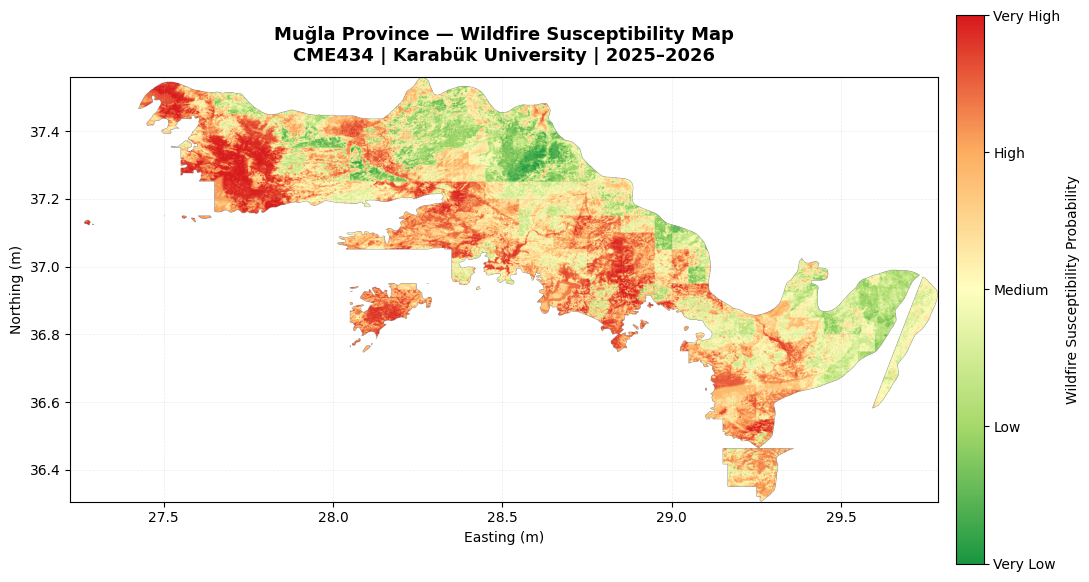

Saved: /content/drive/MyDrive/GIS_Wildfire_Mugla/wildfire_susceptibility_map.png


In [17]:
# Red-yellow-green colormap (high=red, low=green)
cmap = LinearSegmentedColormap.from_list(
    'wildfire', ['#1a9641', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c'])

fig, ax = plt.subplots(figsize=(11, 9))
img = ax.imshow(result, cmap=cmap, vmin=0, vmax=1,
                extent=[transform.c,
                        transform.c + width  * transform.a,
                        transform.f + height * transform.e,
                        transform.f])

cbar = plt.colorbar(img, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Wildfire Susceptibility Probability', fontsize=10)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['Very Low', 'Low', 'Medium', 'High', 'Very High'])

ax.set_title(
    'Muğla Province — Wildfire Susceptibility Map\n'
    'CME434 | Karabük University | 2025–2026',
    fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.grid(alpha=0.25, linestyle='--', linewidth=0.5)

plt.tight_layout()
fig_path = f'{DRIVE}/wildfire_susceptibility_map.png'
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

## Step 9 — Summary Statistics by Risk Class

In [18]:
flat = result[valid_mask]
breaks = [0.0, 0.20, 0.40, 0.60, 0.80, 1.01]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

print('Risk class distribution (% of valid pixels):')
for i, label in enumerate(labels):
    lo, hi = breaks[i], breaks[i+1]
    pct = 100 * ((flat >= lo) & (flat < hi)).sum() / len(flat)
    print(f'  {label:<12}: {pct:5.1f}%')

print(f'\nHigh + Very High: {100*((flat >= 0.60).sum()/len(flat)):.1f}% of Muğla')
print('\nDone.')

Risk class distribution (% of valid pixels):
  Very Low    :   4.2%
  Low         :  17.0%
  Medium      :  27.1%
  High        :  29.2%
  Very High   :  22.4%

High + Very High: 51.6% of Muğla

Done.
